Running on 4 threads...


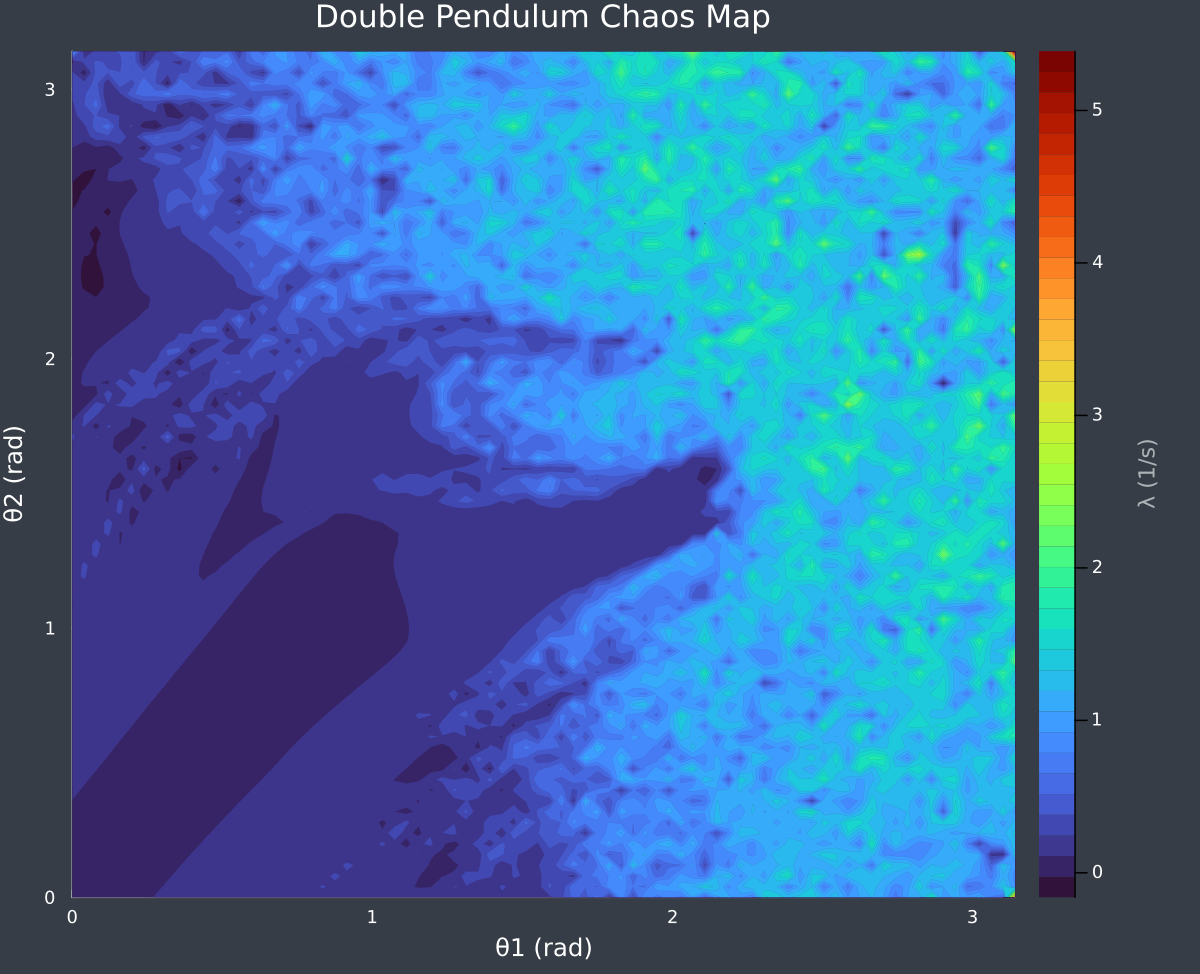

In [1]:
using DifferentialEquations
using Plots
using LinearAlgebra
using Base.Threads

# Double pendulum equations of motion
function double_pendulum!(du, u, p, t)
    θ1, ω1, θ2, ω2 = u
    m1, m2, L1, L2, g = p

    Δ = θ1 - θ2
    denom1 = L1 * (2m1 + m2 - m2 * cos(2Δ))
    denom2 = L2 * (2m1 + m2 - m2 * cos(2Δ))

    du[1] = ω1
    du[2] = (-g * (2m1 + m2) * sin(θ1) - m2 * g * sin(θ1 - 2θ2) -
             2 * sin(Δ) * m2 * (ω2^2 * L2 + ω1^2 * L1 * cos(Δ))) / denom1

    du[3] = ω2
    du[4] = (2 * sin(Δ) * (ω1^2 * L1 * (m1 + m2) + g * (m1 + m2) * cos(θ1) +
             ω2^2 * L2 * m2 * cos(Δ))) / denom2
end

m1, m2 = 1.0, 1.0
L1, L2 = 1.0, 1.0
g = 9.81
p = (m1, m2, L1, L2, g)

function lyapunov_exponent(θ1_0, θ2_0; ϵ=1e-8, t_max=15.0, dt=0.05,
                             abstol=1e-10, reltol=1e-10)
    u0_a = [θ1_0, 0.0, θ2_0, 0.0]
    u0_b = [θ1_0 + ϵ, 0.0, θ2_0, 0.0]

    prob_a = ODEProblem(double_pendulum!, u0_a, (0.0, t_max), p)
    prob_b = ODEProblem(double_pendulum!, u0_b, (0.0, t_max), p)

    sol_a = solve(prob_a, Tsit5(), saveat=dt, abstol=abstol, reltol=reltol)
    sol_b = solve(prob_b, Tsit5(), saveat=dt, abstol=abstol, reltol=reltol)

    n = min(length(sol_a.t), length(sol_b.t))
    log_dists = Float64[]
    times = Float64[]

    for i in 1:n
        dist = norm(sol_a.u[i] .- sol_b.u[i])
        if dist > 0 && isfinite(dist)
            push!(log_dists, log(dist))
            push!(times, sol_a.t[i])
        end
        dist > 10.0 && break
    end

    length(times) < 5 && return 0.0

    t̄, l̄ = sum(times) / length(times), sum(log_dists) / length(log_dists)
    num = sum((times .- t̄) .* (log_dists .- l̄))
    den = sum((times .- t̄) .^ 2)
    return den > 0 ? num / den : 0.0
end

# Build the chaos map, parallelized across the outer grid loop.
# Each thread computes one full column (fixed θ1) independently.
n_grid = 80
θ1_range = range(0, π, length=n_grid)
θ2_range = range(0, π, length=n_grid)

chaos_map = zeros(n_grid, n_grid)

println("Running on $(nthreads()) threads...")

@threads for i in 1:n_grid
    θ1_0 = θ1_range[i]
    for (j, θ2_0) in enumerate(θ2_range)
        chaos_map[i, j] = lyapunov_exponent(θ1_0, θ2_0)
    end
end

# Plot with a refined aesthetic: dark theme, smooth contours, higher DPI
theme(:dark)

contourf(θ1_range, θ2_range, chaos_map',
    xlabel="θ1 (rad)",
    ylabel="θ2 (rad)",
    title="Double Pendulum Chaos Map",
    subtitle="Estimated largest Lyapunov exponent λ",
    color=:turbo,
    levels=40,
    linewidth=0,
    colorbar_title="λ (1/s)",
    size=(800, 650),
    dpi=150,
    right_margin=5Plots.mm)